In [16]:
import pandas as pd
import numpy as np 
from china_air_quality_utils import process_df

In [17]:
beijing_data = pd.read_csv('BeijingPM.csv', index_col=False)
chengdu_data = pd.read_csv('ChengduPM.csv', index_col=False)
guangzhou_data = pd.read_csv('GuangzhouPM.csv', index_col=False)
shanghai_data = pd.read_csv('ShanghaiPM.csv', index_col=False)
shenyang_data = pd.read_csv('ShenyangPM.csv', index_col=False)

data_list = [beijing_data, chengdu_data, guangzhou_data, shanghai_data, shenyang_data]
city_list = {
    0: 'beijing',
    1: 'changdu', 
    2: 'guangzhou', 
    3: 'shanghai', 
    4: 'shenyang'
}

In [18]:
print("Length data")
print("Beijing: ", len(beijing_data))
print("Chengdu: ", len(chengdu_data))
print("Guangzhou: ", len(guangzhou_data))
print("Shanghai: ", len(shanghai_data))
print("Shengyang: ", len(shenyang_data))

Length data
Beijing:  52584
Chengdu:  52584
Guangzhou:  52584
Shanghai:  52584
Shengyang:  52584


In [19]:
for data in data_list:
    print(data.isna().sum())
    break 
    

No                     0
year                   0
month                  0
day                    0
hour                   0
season                 0
PM_Dongsi          27532
PM_Dongsihuan      32076
PM_Nongzhanguan    27653
PM_US Post          2197
DEWP                   5
HUMI                 339
PRES                 339
TEMP                   5
cbwd                   5
Iws                    5
precipitation        484
Iprec                484
dtype: int64


In [20]:
X_list = []
y_list = []
proc_data_list = []
processed_df = pd.DataFrame([])


for i, data in enumerate(data_list):
    print("Process data")
    data = data.drop('No', axis=1)
    data = data.dropna()
    
    data['season'] = data['season'].astype(int)
    print(data.head())
    new_data, X, y = process_df(data)
    X['env'] = city_list[i]
    print(X.columns)
    proc_data_list.append(new_data)
    print(len(new_data))
    X_list.append(X)
    y_list.append(y)

    process_Xy = pd.concat([X, y], axis=1)
    # print(process_Xy)
    processed_df = pd.concat([processed_df, process_Xy], axis=0)


Process data
       year  month  day  hour  season  PM_Dongsi  PM_Dongsihuan  \
27824  2013      3    5     8       1      117.0          166.0   
27825  2013      3    5     9       1      131.0          165.0   
27826  2013      3    5    10       1      141.0          173.0   
27828  2013      3    5    12       1      169.0          182.0   
27829  2013      3    5    13       1      169.0          169.0   

       PM_Nongzhanguan  PM_US Post  DEWP  HUMI    PRES  TEMP cbwd   Iws  \
27824            140.0       150.0  -6.0  59.0  1019.0   1.0   cv  0.89   
27825            152.0       163.0  -8.0  38.0  1019.0   5.0   cv  1.78   
27826            128.0       172.0  -8.0  31.0  1018.0   8.0   cv  2.67   
27828              3.0       181.0  -9.0  23.0  1017.0  11.0   cv  4.45   
27829              3.0       187.0  -9.0  22.0  1015.0  12.0   cv  5.34   

       precipitation  Iprec  
27824            0.0    0.0  
27825            0.0    0.0  
27826            0.0    0.0  
27828        

In [21]:
processed_df.isna().sum()
processed_df = processed_df.fillna(False)
processed_df
# # # pro

# processed_df.to_csv('china_air_quality_2.csv')

/tmp/ipykernel_28879/2563109498.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  processed_df = processed_df.fillna(False)


,Season,DewPt,Humidity,Press,TempC,WindSp,PrecipHr,PrecipCm,WindDir_NW,WindDir_SE,WindDir_cv,env,target,WindDir_SW
2013-03-05 08:00:00,1,-6.0,59.00,1019.0,1.0,0.636577,0.0,0.0,False,False,True,beijing,4.971548,False
2013-03-05 09:00:00,1,-8.0,38.00,1019.0,5.0,1.022451,0.0,0.0,False,False,True,beijing,5.035328,False
2013-03-05 10:00:00,1,-8.0,31.00,1018.0,8.0,1.300192,0.0,0.0,False,False,True,beijing,5.040194,False
2013-03-05 12:00:00,1,-9.0,23.00,1017.0,11.0,1.695616,0.0,0.0,False,False,True,beijing,4.903421,False
2013-03-05 13:00:00,1,-9.0,22.00,1015.0,12.0,1.846879,0.0,0.0,False,False,True,beijing,4.890349,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-12-31 17:00:00,4,-9.0,68.11,1030.0,-4.0,1.386294,0.0,0.0,False,True,False,shenyang,5.103923,False
2015-12-31 18:00:00,4,-11.0,78.94,1031.0,-8.0,0.000000,0.0,0.0,False,False,True,shenyang,5.361292,False
2015-12-31 19:00:00,4,-10.0,92.42,1031.0,-9.0,1.098612,0.0,0.0,False,True,False,shenyang,5.542570,False
2015-12-31 20:00:00,4,-10.0,79.10,1030.0,-7.0,1.791759,0.0,0.0,False,True,False,shenyang,5.753630,False


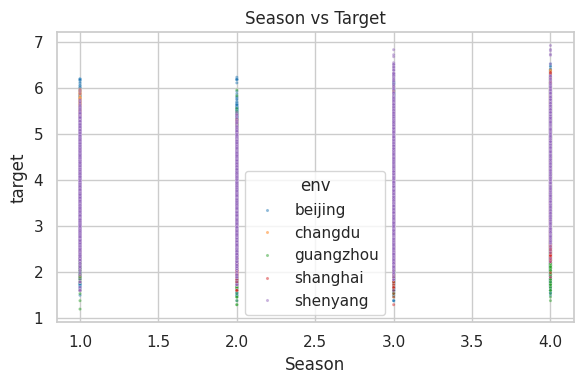

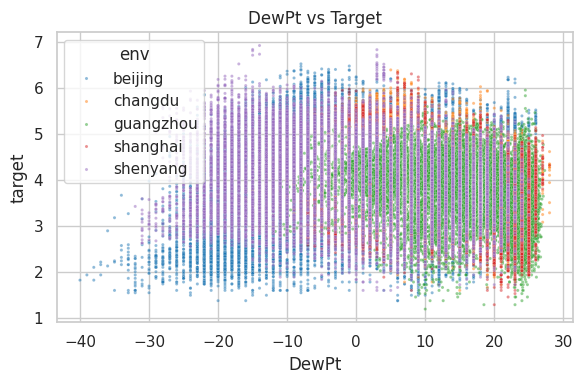

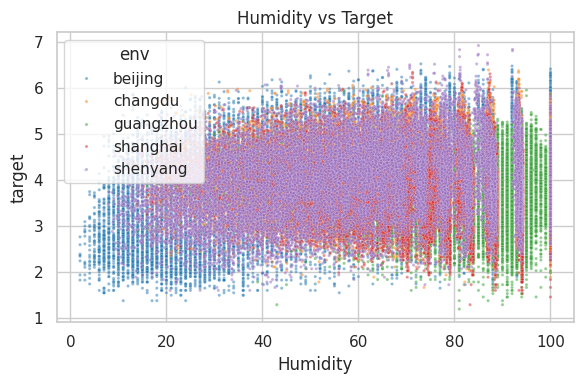

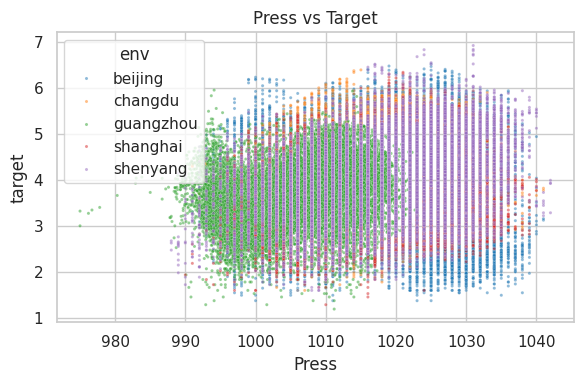

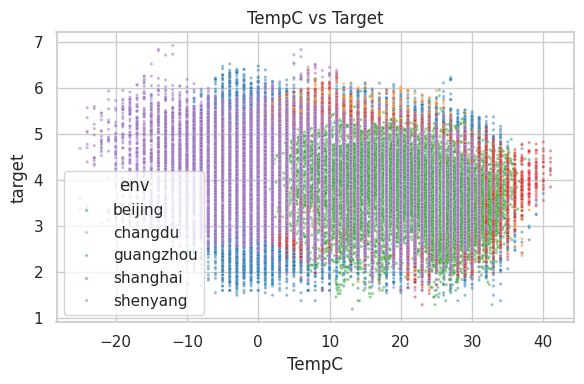

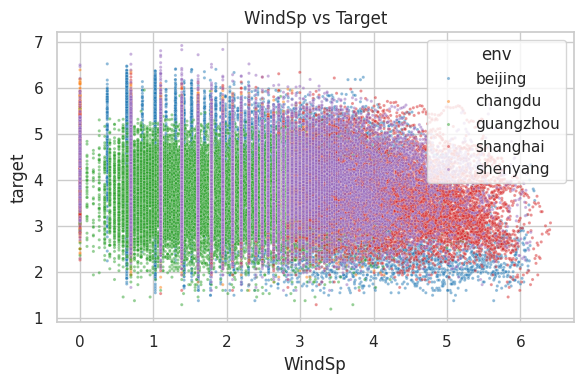

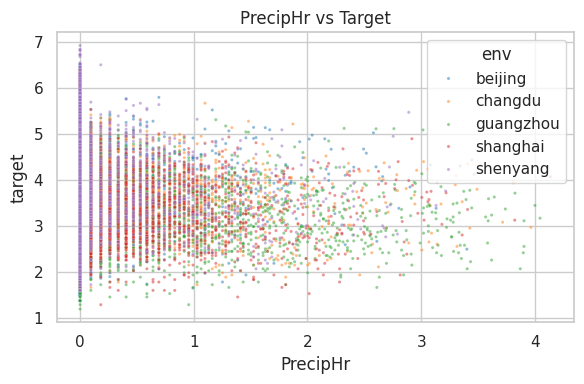

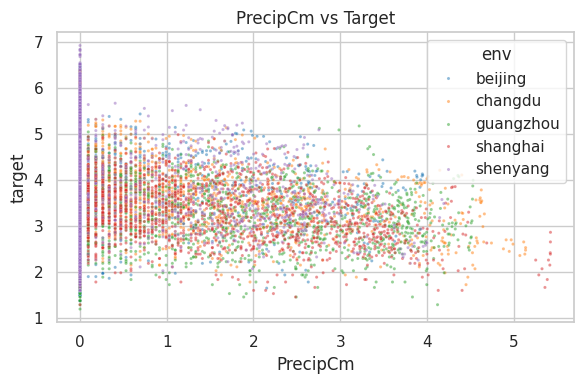

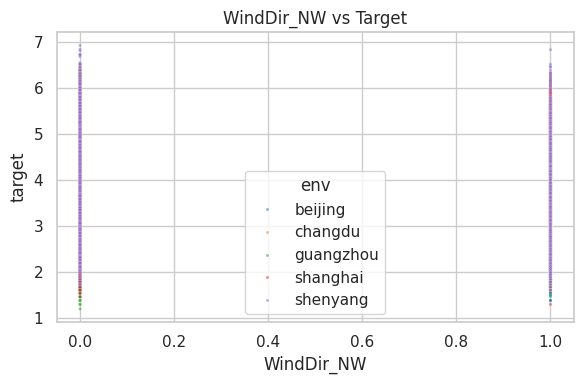

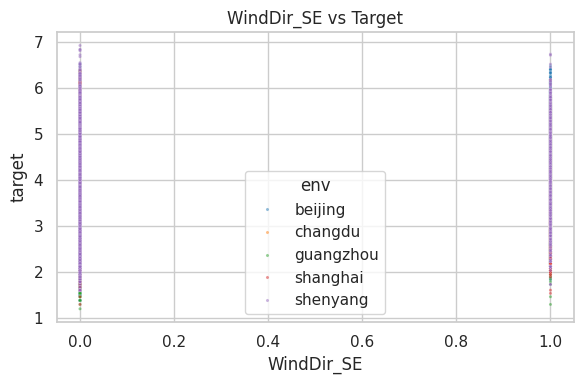

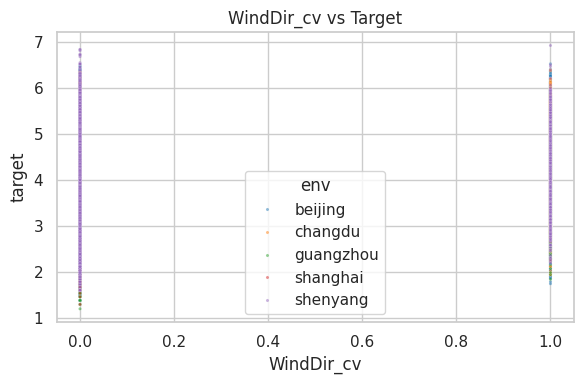

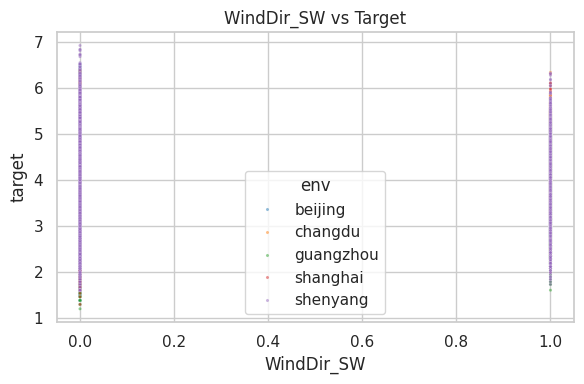

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is called `df`
features = ['Season', 'DewPt', 'Humidity', 'Press', 'TempC', 'WindSp', 
            'PrecipHr', 'PrecipCm', 'WindDir_NW', 'WindDir_SE', 'WindDir_cv', 'WindDir_SW']

# Set the style for better visuals
sns.set(style="whitegrid")

# Plot each feature against the target
for feature in features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=processed_df, x=feature, y='target', hue='env', palette='tab10',  s=5, alpha=0.5)
    plt.title(f'{feature} vs Target')
    plt.tight_layout()
    plt.show()


In [ ]:
X_list = []
y_list = []
proc_data_list = []
processed_df = pd.DataFrame([])

for i, data in enumerate(data_list):
    print("Process data")
    data = data.drop('No', axis=1)
    data = data.dropna()
    
    data['season'] = data['season'].astype(int)
    print(data.head())
    new_data, X, y = process_df(data)
    X['env'] = city_list[i]
    print(X.columns)
    proc_data_list.append(new_data)
    print(len(new_data))
    X_list.append(X)
    y_list.append(y)

    process_Xy = pd.concat([X, y], axis=1)
    # print(process_Xy)
    processed_df = pd.concat([processed_df, process_Xy], axis=0)


In [ ]:
season_data_list = []
reverse_city_list = {
    'beijing': 0,
    'changdu': 1,
    'guangzhou': 2,
    'shanghai': 3,
    'shenyang': 4
}
id_list = {}
for i, (id, season_data) in  enumerate(processed_df.groupby(['Season', 'env'])):
    id_list[i] = id
    # season_data['env'] = season_data['env'].map(reverse_city_list)
    season_data_list.append(season_data)

(np.int64(1), 'beijing')
(np.int64(1), 'changdu')
(np.int64(1), 'guangzhou')
(np.int64(1), 'shanghai')
(np.int64(1), 'shenyang')
(np.int64(2), 'beijing')
(np.int64(2), 'changdu')
(np.int64(2), 'guangzhou')
(np.int64(2), 'shanghai')
(np.int64(2), 'shenyang')
(np.int64(3), 'beijing')
(np.int64(3), 'changdu')
(np.int64(3), 'guangzhou')
(np.int64(3), 'shanghai')
(np.int64(3), 'shenyang')
(np.int64(4), 'beijing')
(np.int64(4), 'changdu')
(np.int64(4), 'guangzhou')
(np.int64(4), 'shanghai')
(np.int64(4), 'shenyang')


KeyError: 4

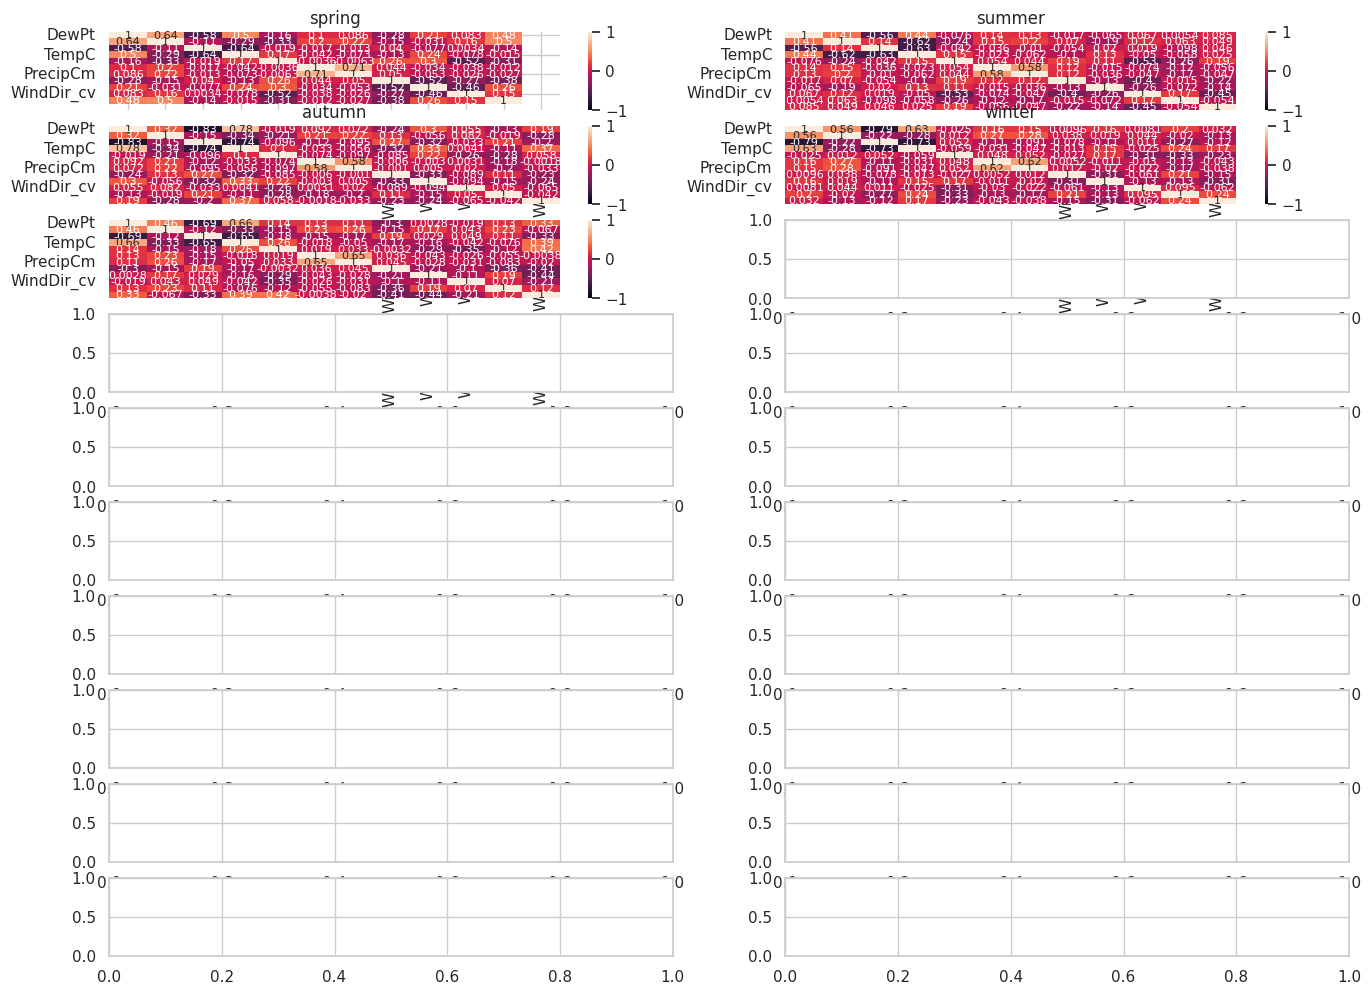

In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns 
import math
import pandas as pd  # Required for pd.concat if not already imported


season_list = {
    0: 'spring',
    1: 'summer', 
    2: 'autumn', 
    3: 'winter'
}

# construct axes 
ncols = 2

nrows = math.ceil(len(season_data_list) / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16,12))
axes = axes.flatten()

# Loop through city_list
for idx, value in enumerate(season_data_list):
    # data = pd.concat([X_list[idx].drop(columns=['env']), y_list[idx]], axis=1)
    sns.heatmap(
        value.drop(columns=['Season', 'env']).corr(), 
        ax=axes[idx], 
        annot=True, 
        vmin=-1, vmax=1,            # Fix the color scale
        annot_kws={'size': 8}       # Smaller annotation font size
)
    axes[idx].set_title(season_list[idx])

# Remove unused subplots
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# TODO: run with avg_pm 
# TODO: run experiment

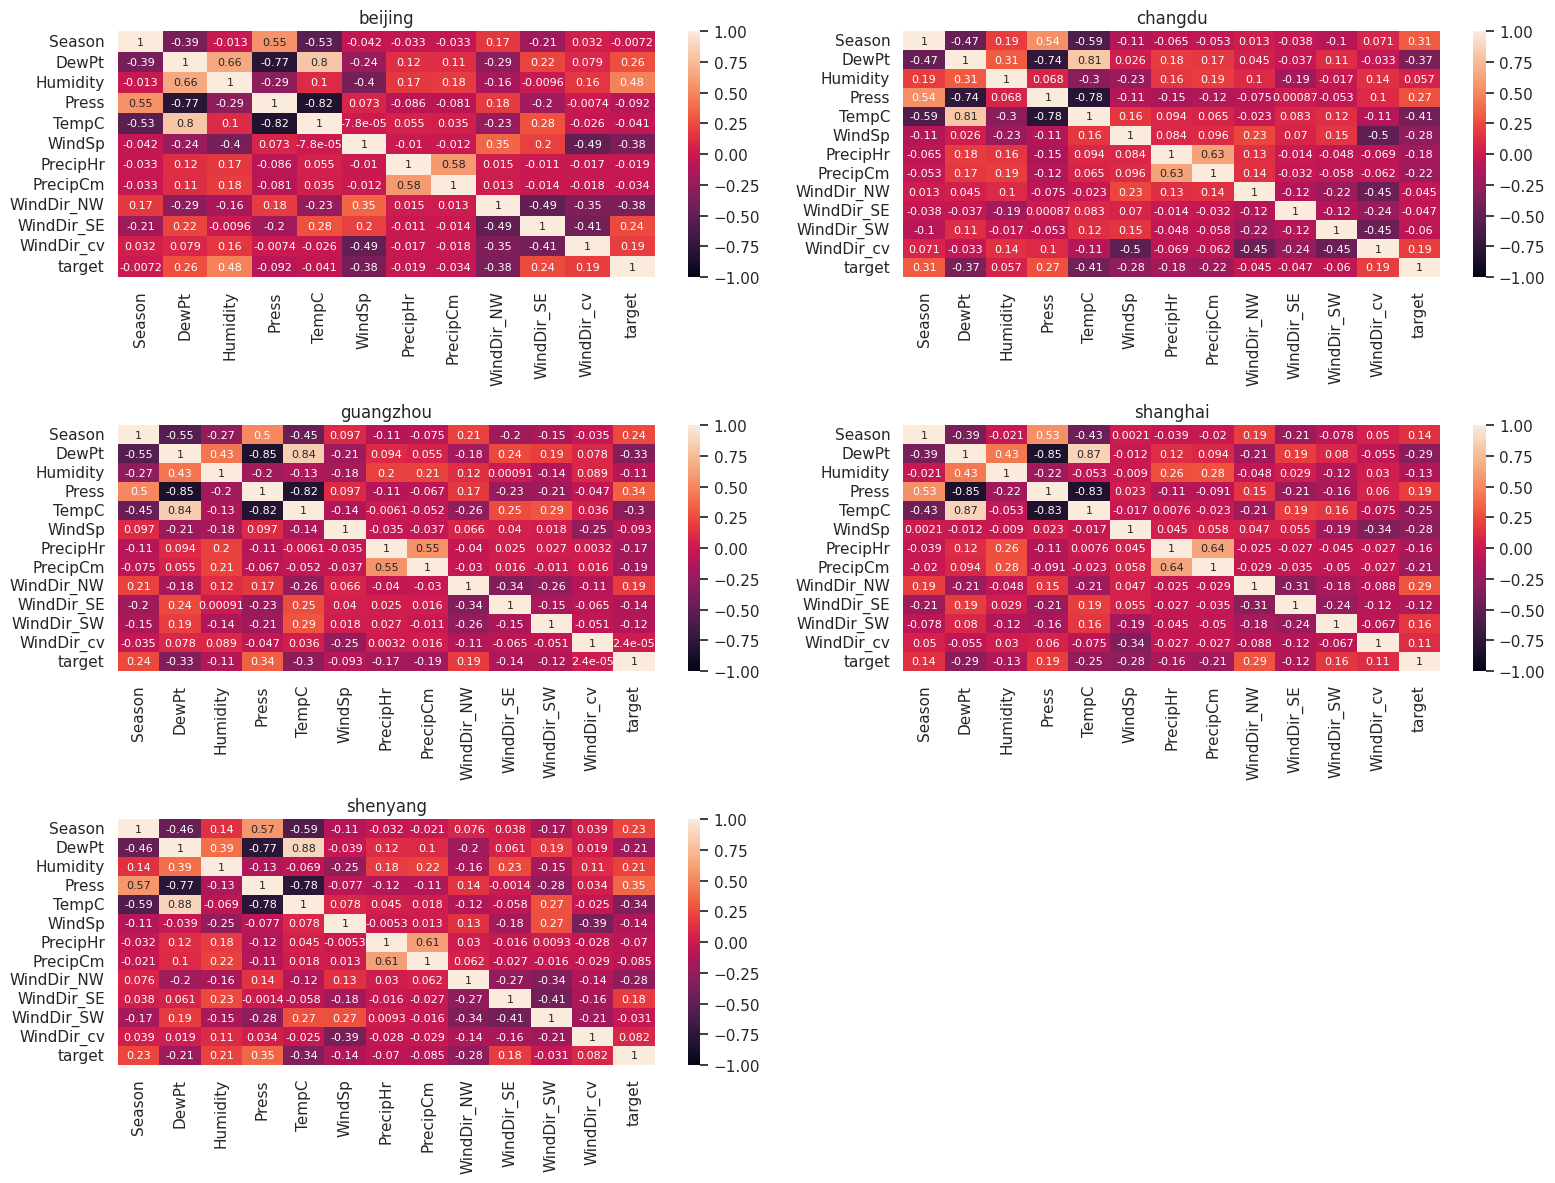

In [25]:
import matplotlib.pyplot as plt 
import seaborn as sns 
import math
import pandas as pd  # Required for pd.concat if not already imported

# construct axes 
ncols = 2

nrows = math.ceil(len(city_list) / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16,12))
axes = axes.flatten()

# Loop through city_list
for i, (idx, value) in enumerate(city_list.items()):
    data = pd.concat([X_list[idx].drop(columns=['env']), y_list[idx]], axis=1)
    sns.heatmap(
        data.corr(), 
        ax=axes[i], 
        annot=True, 
        vmin=-1, vmax=1,            # Fix the color scale
        annot_kws={'size': 8}       # Smaller annotation font size
)
    axes[i].set_title(value)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# TODO: run with avg_pm 
# TODO: run experiment